# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


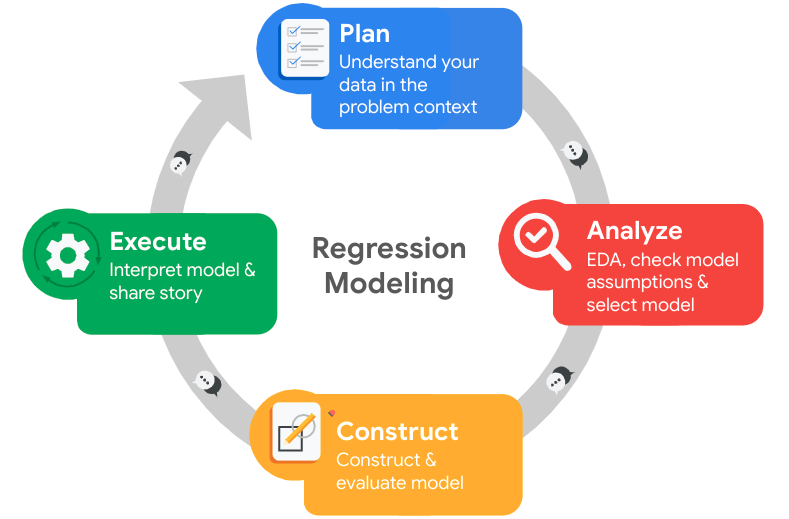

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




## Plan Stage

### Stakeholders
- HR team (employee retention decisions)  
- Senior management (cost & productivity impact)  
- Team managers (workload and performance tracking)  

### Business Problem
- Predict employee attrition (`left = 1`)  
- Identify key drivers of employee turnover  
- Reduce hiring and training costs  

### Initial Observations
- Dataset contains no missing values  
- High number of duplicates (~3000), which were removed  
- Target variable is imbalanced (~16.6% attrition rate)  
- Includes both behavioral and organizational features  

### Resources Used
- Scikit-learn: https://scikit-learn.org  
- XGBoost: https://xgboost.readthedocs.io  
- Seaborn: https://seaborn.pydata.org  

### Ethical Considerations
- Avoid bias across departments and salary groups  
- Ensure responsible use of predictions  
- Maintain employee data privacy 

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree



### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###

df0.head(20)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###

df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###


df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###

df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns = {'Work_accident': 'work_accident',
                           'Department':'department',
                           'time_spend_company': 'tenure',
                           'average_montly_hours':'avg_monthly_hours'})

# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###

df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
avg_monthly_hours        0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###

df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###

df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###

df1.head()


,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

<function matplotlib.pyplot.show(*args, **kw)>

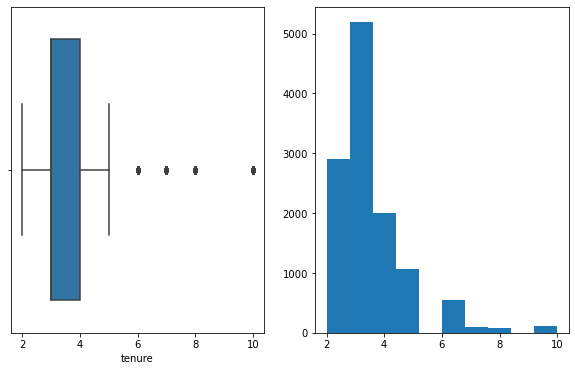

<Figure size 432x288 with 0 Axes>

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###

fig, ax = plt.subplots(1,2, figsize = (10,6))

plt.figure()

sns.boxplot(x = df1['tenure'], ax =ax[0])

ax[1].hist(df1['tenure'])

plt.tight_layout()

plt.show

In [12]:
# Determine the number of rows containing outliers 

percentile25 = df1['tenure'].quantile(0.25)

percentile75 = df1['tenure'].quantile(0.75)


iqr = percentile75 - percentile25


upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)


outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]


print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [13]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###

print(df1['left'].value_counts())

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###


df1['left'].value_counts(normalize =  True)

0    10000
1     1991
Name: left, dtype: int64


0    0.833959
1    0.166041
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

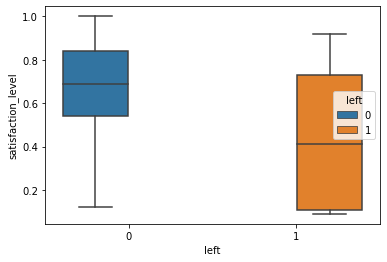

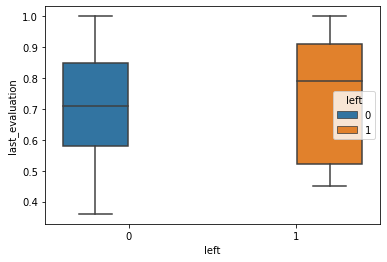

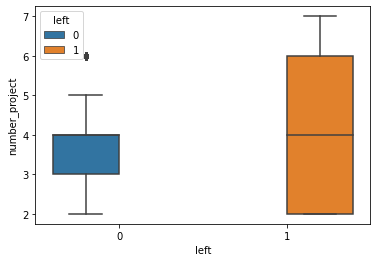

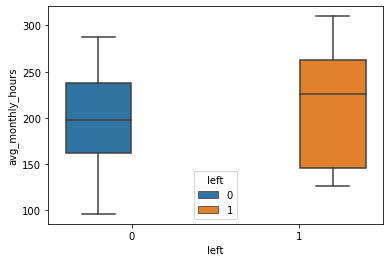

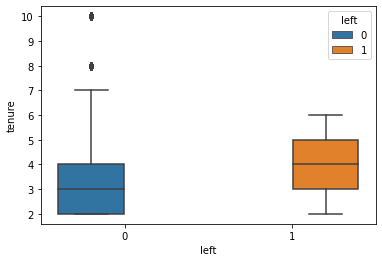

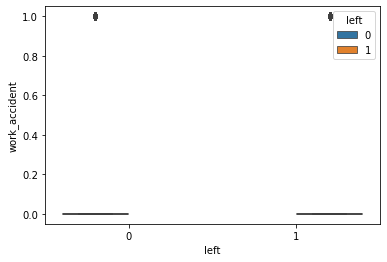

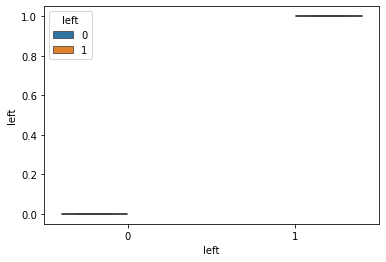

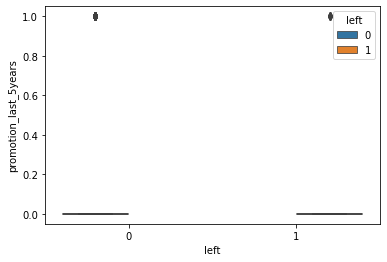

In [14]:
# Create a plot as needed
### YOUR CODE HERE ###
###sns.set_theme(style="darkgrid")

for col in df1.select_dtypes("number"):
    ax= sns.boxplot(data=df1, x="left", y=col, hue= 'left')
    
    plt.show()
    
    

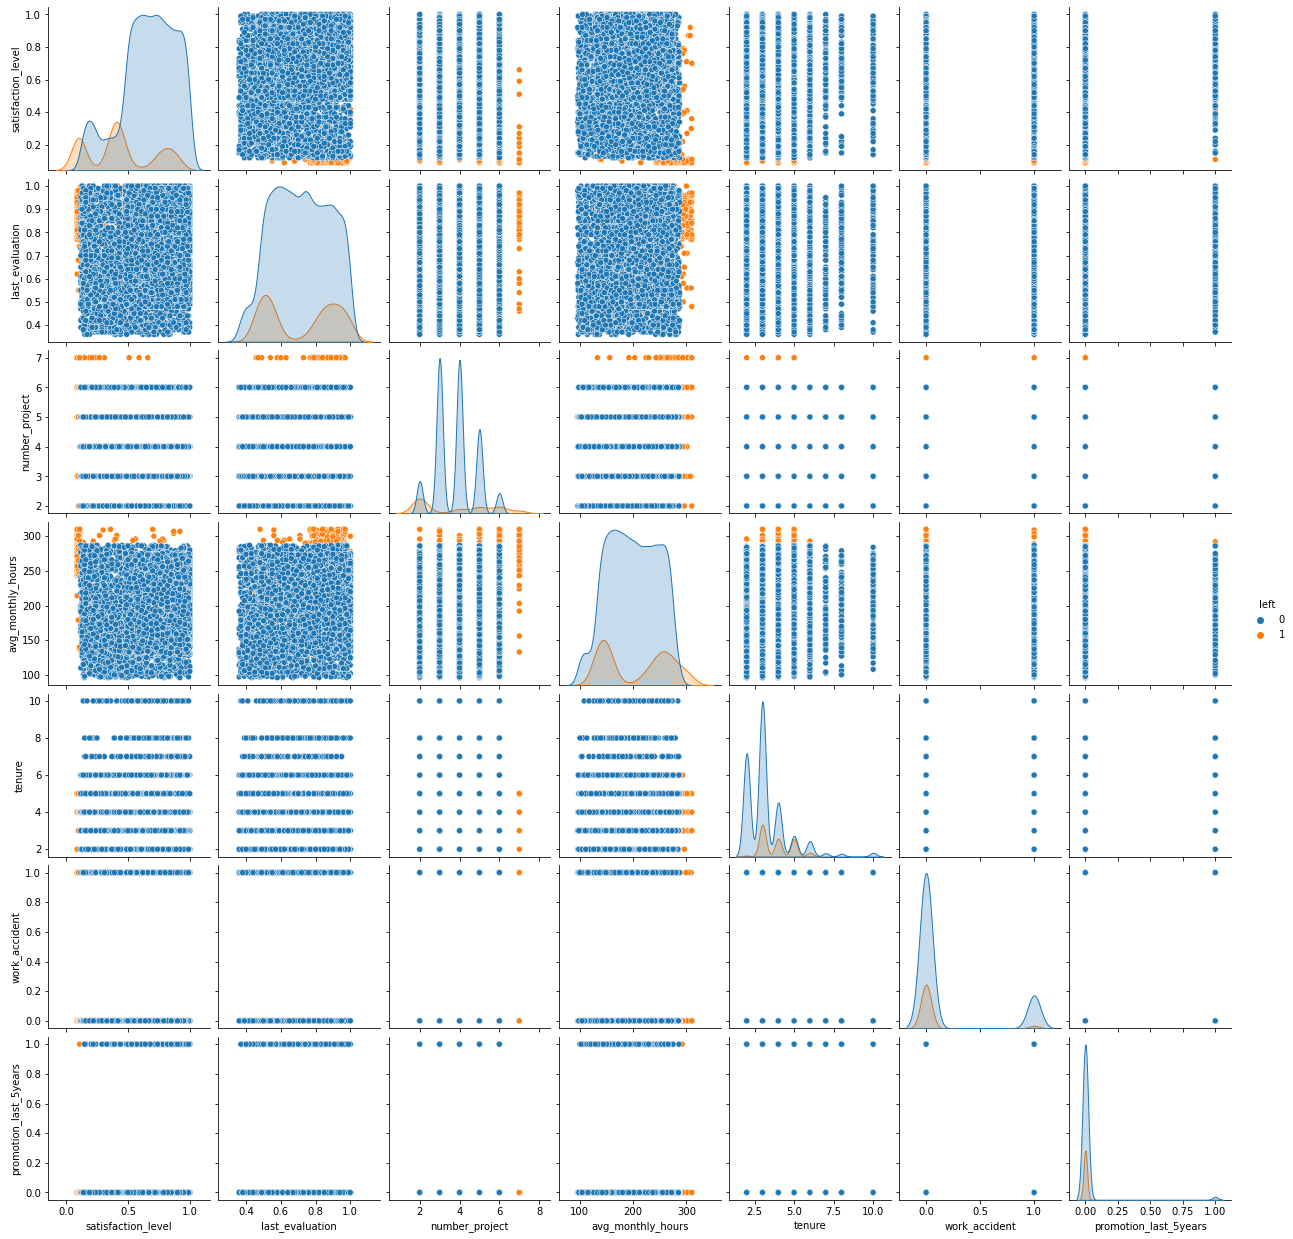

In [15]:
# Create a plot as needed
### YOUR CODE HERE ###


sns.pairplot(df1, hue = 'left');

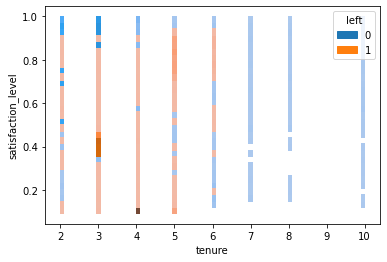

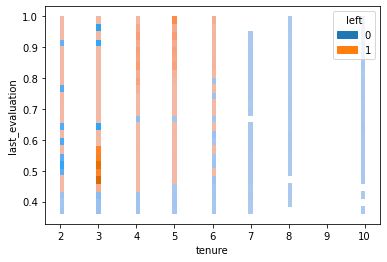

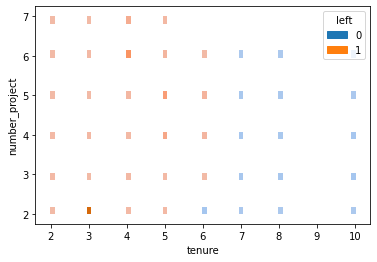

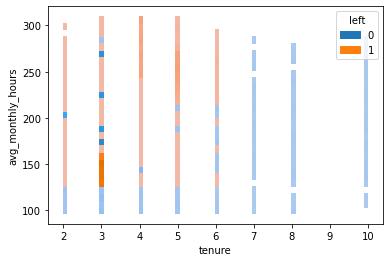

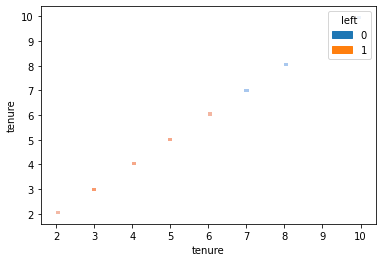

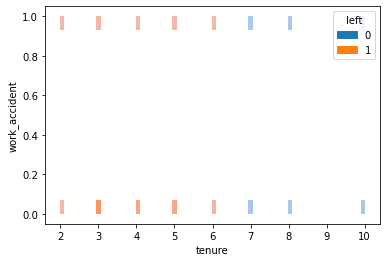

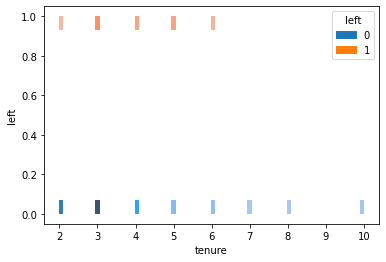

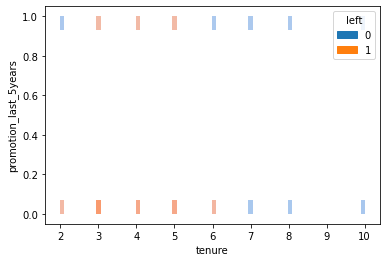

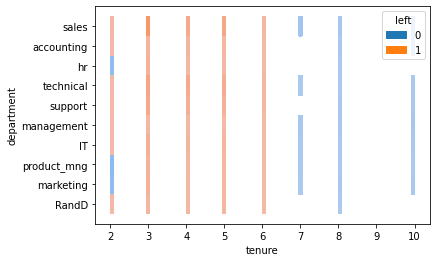

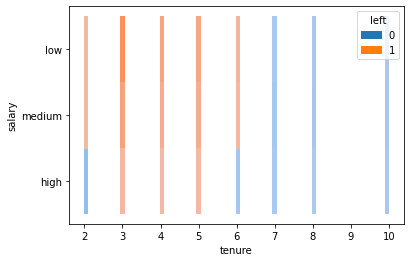

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###

for col in df1:
    ax= sns.histplot(data=df1, x="tenure", y=col, hue= 'left')
    
    plt.show()



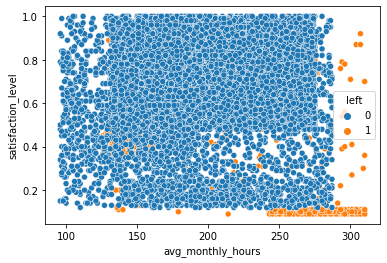

In [17]:
# Create a plot as needed
### YOUR CODE HERE ###

sns.scatterplot(data = df1, x = 'avg_monthly_hours', y = 'satisfaction_level', hue = 'left')


plt.show()

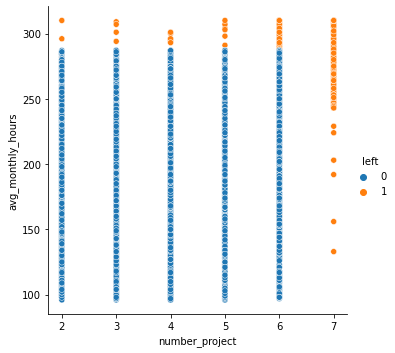

In [18]:
# Create a plot as needed
### YOUR CODE HERE ###


sns.relplot(data = df1, x = 'number_project', y ='avg_monthly_hours', hue= 'left')
plt.show()

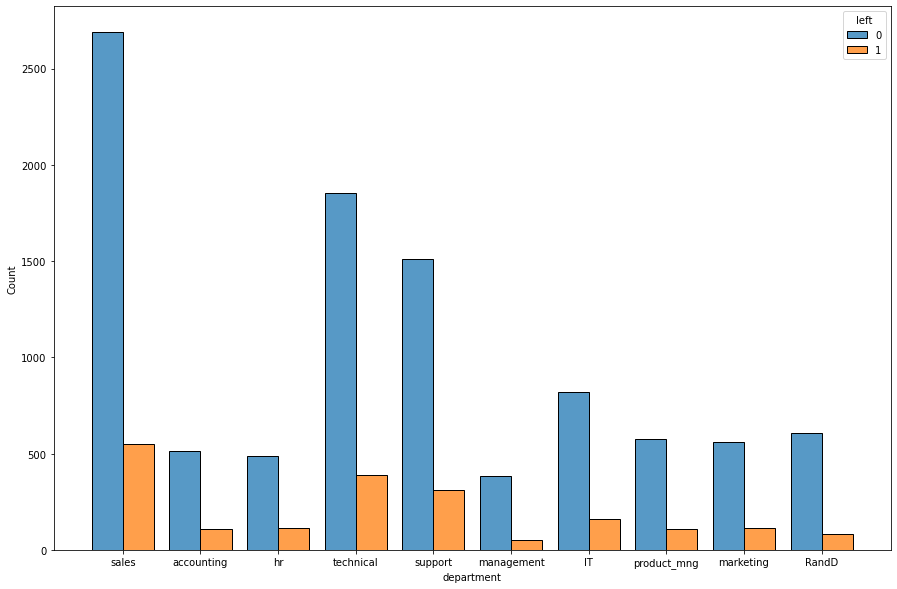

In [19]:
# Create a plot as needed
### YOUR CODE HERE ###

plt.figure(figsize= (15,10))
sns.histplot(data = df1, x= 'department', hue = 'left', multiple = 'dodge',shrink = 0.8 )
plt.show()

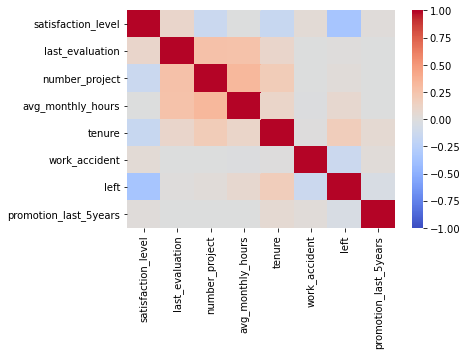

In [20]:
# Create a plot as needed
### YOUR CODE HERE ###

sns.heatmap(df1.select_dtypes(include='number').corr(),
            vmin=-1,
            vmax=1,
            cmap='coolwarm')

In [21]:
# Create a plot as needed
### YOUR CODE HERE ###
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   avg_monthly_hours      11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.3+ MB


### Insights


### Relationships Between Variables
- Low satisfaction level is strongly associated with attrition  
- High monthly hours and number of projects indicate burnout  
- Employees with low salaries are more likely to leave  
- Lack of promotion increases attrition risk  

### Distributions
- Satisfaction shows clustering at low and high values  
- Monthly working hours vary widely  
- Tenure contains some outliers  



# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



## Construct Stage

### Type of Prediction Task
- Binary classification  

### Models Used
- Logistic Regression (baseline model)  
- Random Forest  
- XGBoost  

### Observations
- Logistic Regression underperformed  
- Tree-based models performed significantly better  

### Model Assumptions
- Logistic Regression assumptions partially violated:
  - Non-linear relationships present  
  - Possible multicollinearity  

### Model Performance
- Logistic Regression: moderate performance  
- Random Forest and XGBoost: strong performance  

### Improvements
- Hyperparameter tuning  
- Feature engineering  
- Handling class imbalance  

### Ethical Considerations
- Avoid overfitting  
- Ensure fairness across employee groups  

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

- Binary classification  

### Identify the types of models most appropriate for this task.

- Logistic Regression (baseline model)  
- Random Forest  
- XGBoost  

### Modeling

Add as many cells as you need to conduct the modeling process.

In [22]:
### YOUR CODE HERE ###

y = df1['left']




In [23]:
X = df1.drop(['left'],axis = 1)

X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11991 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   avg_monthly_hours      11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   promotion_last_5years  11991 non-null  int64  
 7   department             11991 non-null  object 
 8   salary                 11991 non-null  object 
dtypes: float64(2), int64(5), object(2)
memory usage: 1.2+ MB


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [25]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8993, 9), (2998, 9), (8993,), (2998,))

In [26]:
X_train["department"].unique()

array(['technical', 'sales', 'product_mng', 'marketing', 'RandD', 'IT',
       'support', 'management', 'hr', 'accounting'], dtype=object)

In [27]:
X_train["salary"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [28]:
X_train_to_encode = X_train[["department", "salary"]]

X_train_to_encode.head()

,department,salary
6302,technical,low
4143,sales,low
8236,product_mng,low
7936,marketing,low
8547,RandD,low


In [29]:
from sklearn.preprocessing import OneHotEncoder

X_encoder = OneHotEncoder(drop='first', sparse=False)

In [30]:
X_train_encoded = X_encoder.fit_transform(X_train_to_encode)

In [31]:
X_train_encoded

array([[0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [32]:
X_train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=X_encoder.get_feature_names())

X_train_encoded_df.head(20)

,x0_RandD,x0_accounting,x0_hr,x0_management,x0_marketing,x0_product_mng,x0_sales,x0_support,x0_technical,x1_low,x1_medium
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [33]:
X_train.drop(columns=["department", "salary"]).head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,tenure,work_accident,promotion_last_5years
6302,0.68,0.79,5,139,4,0,0
4143,1.00,1.00,5,142,4,0,0
8236,0.56,0.80,5,202,4,0,0
7936,0.51,0.71,4,208,3,1,0
8547,0.70,0.57,5,247,3,0,0


In [34]:
X_train_final = pd.concat([X_train.drop(columns=["department", "salary"]).reset_index(drop=True), X_train_encoded_df], axis=1)


X_train_final.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,tenure,work_accident,promotion_last_5years,x0_RandD,x0_accounting,x0_hr,x0_management,x0_marketing,x0_product_mng,x0_sales,x0_support,x0_technical,x1_low,x1_medium
0,0.68,0.79,5,139,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.00,1.00,5,142,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.56,0.80,5,202,4,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.51,0.71,4,208,3,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.70,0.57,5,247,3,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [35]:
y_train.unique()

array([0, 1])

## Logistic Regression Model

In [36]:
log_clf = LogisticRegression(random_state=0, max_iter=800, class_weight='balanced', solver = 'liblinear').fit(X_train_final, y_train)

In [37]:
X_test_to_encode = X_test[["department", "salary"]]

X_test_to_encode.head()

,department,salary
9136,support,low
4836,accounting,low
11041,hr,low
9476,sales,medium
3728,product_mng,medium


In [38]:
X_test_encoded = X_encoder.transform(X_test_to_encode)

# Display first few rows of encoded testing features
X_test_encoded

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [39]:
X_test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=X_encoder.get_feature_names())

# Display first few rows
X_test_encoded_df.head()

,x0_RandD,x0_accounting,x0_hr,x0_management,x0_marketing,x0_product_mng,x0_sales,x0_support,x0_technical,x1_low,x1_medium
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [40]:
X_test_final = pd.concat([X_test.drop(columns=["department", "salary"]).reset_index(drop=True), X_test_encoded_df], axis=1)

X_test_final.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,tenure,work_accident,promotion_last_5years,x0_RandD,x0_accounting,x0_hr,x0_management,x0_marketing,x0_product_mng,x0_sales,x0_support,x0_technical,x1_low,x1_medium
0,0.98,0.62,2,240,3,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.50,0.84,3,156,4,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.48,0.49,3,268,3,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.80,0.84,3,251,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.21,0.37,4,129,4,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [41]:
y_pred = log_clf.predict(X_test_final)

In [42]:
y_pred

array([0, 1, 1, ..., 0, 0, 1])

In [43]:
y_test

9136     0
4836     0
11041    0
9476     0
3728     0
        ..
7597     0
11271    0
3353     0
10291    0
446      1
Name: left, Length: 2998, dtype: int64

In [44]:
y_probs = (y_pred > 0.45).astype(int)

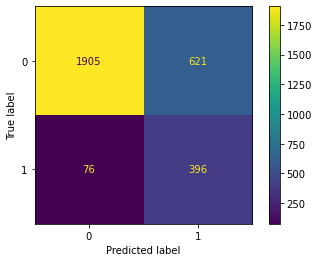

In [45]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot(values_format='d')

# Display plot
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.75      0.85      2526
           1       0.39      0.84      0.53       472

    accuracy                           0.77      2998
   macro avg       0.68      0.80      0.69      2998
weighted avg       0.87      0.77      0.80      2998



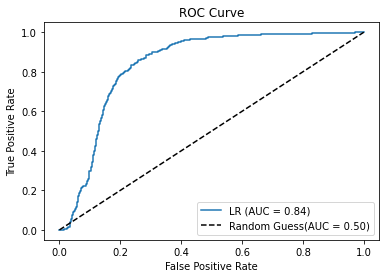

In [47]:
from sklearn.metrics import roc_curve, auc

y_probs = log_clf.predict_proba(X_test_final)[:,1]
fpr1, tpr1, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label = f'LR (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--',label = 'Random Guess(AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

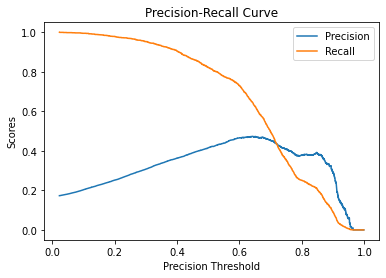

In [48]:
from sklearn.metrics import precision_recall_curve

p_curve, r_curve , t_curve = precision_recall_curve(y_train,log_clf.predict_proba(X_train_final)[:,1])

plt.plot(t_curve, p_curve[:-1], label = 'Precision')
plt.plot(t_curve, r_curve[:-1], label = 'Recall')


plt.xlabel('Precision Threshold')
plt.ylabel('Scores')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## Random Forest with Cross Validation Model

In [49]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [None],
             'max_features': [1.0,2.0,3.0,4.0,5.0],
             'max_samples': [0.25,0.5,0.75,1.0],
             'min_samples_leaf': [2],
             'min_samples_split': [2],
             'n_estimators': [300],
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [50]:
%%time

rf_cv.fit(X_train_final, y_train)

CPU times: user 51.7 s, sys: 249 ms, total: 52 s
Wall time: 52 s


GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=42,
                                  

In [51]:
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.75,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [52]:
rf_cv.best_score_

0.913114469341671

In [53]:
rf_cv_pred = rf_cv.best_estimator_.predict(X_test_final)

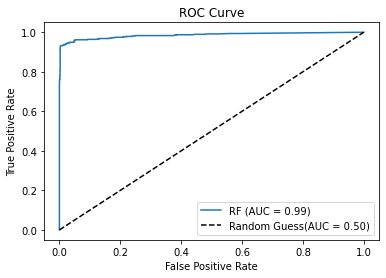

In [54]:
y_probs = rf_cv.predict_proba(X_test_final)[:,1]
fpr1, tpr1, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label = f'RF (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--',label = 'Random Guess(AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [55]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train, rf_cv.best_estimator_.predict_proba(X_train_final)[:,1])
test_auc  = roc_auc_score(y_test,  rf_cv.best_estimator_.predict_proba(X_test_final)[:,1])

print(train_auc, test_auc)

0.9998365190681657 0.9850810050055692


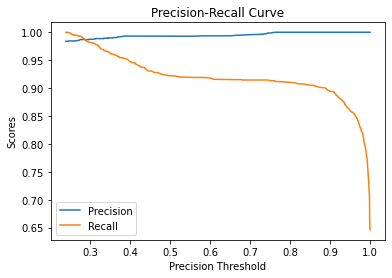

In [56]:
from sklearn.metrics import precision_recall_curve

p_curve, r_curve , t_curve = precision_recall_curve(y_train,rf_cv.predict_proba(X_train_final)[:,1])

plt.plot(t_curve, p_curve[:-1], label = 'Precision')
plt.plot(t_curve, r_curve[:-1], label = 'Recall')


plt.xlabel('Precision Threshold')
plt.ylabel('Scores')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()



In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_cv_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2526
           1       0.98      0.93      0.96       472

    accuracy                           0.99      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



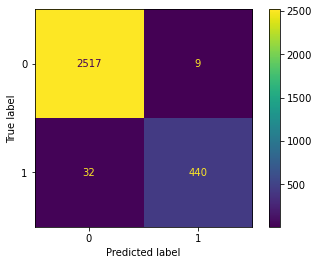

In [58]:
preds = rf_cv.best_estimator_.predict(X_test_final)
cm = confusion_matrix(y_test, preds, labels=rf_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf_cv.classes_)
disp.plot(values_format='');

## XGBoosting Model

In [59]:
from sklearn.model_selection import RandomizedSearchCV

In [60]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [6,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [200]
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = RandomizedSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='recall', n_jobs = -1)

In [61]:
%%time
xgb_cv.fit(X_train_final, y_train)

CPU times: user 25min 51s, sys: 7.39 s, total: 25min 59s
Wall time: 14min 8s


RandomizedSearchCV(cv=4, error_score=nan,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, gamma=None,
                                           gpu_id=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=No...
                                           objective='binary:logistic',
                                           predictor=None, random_

In [62]:
xgb_cv.best_params_

{'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.1}

In [63]:
xgb_cv.best_score_

0.9144077211498403

In [64]:
xgb_cv_pred = xgb_cv.best_estimator_.predict(X_test_final)

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_cv_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2526
           1       0.98      0.93      0.95       472

    accuracy                           0.99      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



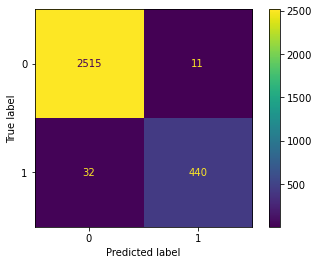

In [66]:
preds = xgb_cv.best_estimator_.predict(X_test_final)
cm = confusion_matrix(y_test, preds, labels=xgb_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=xgb_cv.classes_)
disp.plot(values_format='');

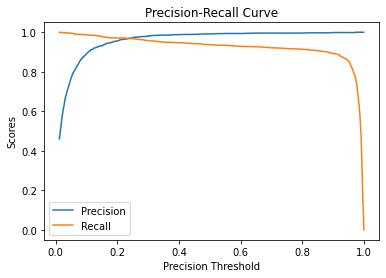

In [67]:
p_curve, r_curve , t_curve = precision_recall_curve(y_train,xgb_cv.predict_proba(X_train_final)[:,1])

plt.plot(t_curve, p_curve[:-1], label = 'Precision')
plt.plot(t_curve, r_curve[:-1], label = 'Recall')


plt.xlabel('Precision Threshold')
plt.ylabel('Scores')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


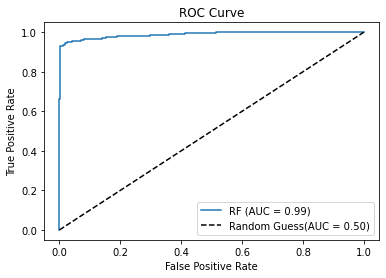

In [69]:
y_probs = xgb_cv.predict_proba(X_test_final)[:,1]
fpr1, tpr1, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label = f'RF (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--',label = 'Random Guess(AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [68]:
train_auc = roc_auc_score(y_train, rf_cv.best_estimator_.predict_proba(X_train_final)[:,1])
test_auc  = roc_auc_score(y_test,  rf_cv.best_estimator_.predict_proba(X_test_final)[:,1])

print(train_auc, test_auc)

0.9998365190681657 0.9850810050055692


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



### Key Insights
- Low satisfaction is the strongest predictor of attrition  
- High workload contributes significantly to employee exit  
- Low salary increases likelihood of leaving  
- Lack of promotions is a major factor  

### Model Performance Highlights
- Random Forest and XGBoost achieved ~99% accuracy  
- High recall ensures most attrition cases are identified  

---

## Business Recommendations

1. Improve employee satisfaction through regular feedback  
2. Monitor and manage employee workload  
3. Provide clear promotion and growth opportunities  
4. Review compensation for low-salary employees  
5. Use predictive models for early intervention  

---

## Model Improvement
 
- Create new features (e.g., workload ratios)  
- Experiment with additional models  

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

| Model                | Accuracy | Recall (Attrition) | Precision (Attrition) |
|---------------------|---------|--------------------|----------------------|
| Logistic Regression | ~77%    | 0.84               | 0.39                 |
| Random Forest       | ~99%    | 0.93               | 0.98                 |
| XGBoost             | ~99%    | 0.93               | 0.98                 |

### Conclusion
- Employee attrition is driven by satisfaction, workload, and salary  
- Tree-based models provide highly accurate predictions  

### Next Steps
- Deploy model for HR decision-making  
- Build dashboards for monitoring attrition risk  
- Continuously retrain model with new data  

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.